## Import Library

In [4]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize
from tqdm import tqdm

from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser

from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 13})

## Konfigurasi (Parameter Terbaik — Tanpa Grid Search)

In [5]:
BEST_K     = 3
BEST_ALPHA = 0.8

RANDOM_SEED = 42
TEXT_COL    = 'review_text'
RATING_MIN  = 1.0
RATING_MAX  = 5.0

SIGNIFICANCE_GAMMA = 10

print(f"BEST_K              : {BEST_K}")
print(f"BEST_ALPHA          : {BEST_ALPHA}  (KNN={BEST_ALPHA:.0%}, CBF={1-BEST_ALPHA:.0%})")
print(f"Rating clip         : [{RATING_MIN}, {RATING_MAX}]")
print(f"SIGNIFICANCE_GAMMA  : {SIGNIFICANCE_GAMMA}")

BEST_K              : 3
BEST_ALPHA          : 0.8  (KNN=80%, CBF=20%)
Rating clip         : [1.0, 5.0]
SIGNIFICANCE_GAMMA  : 10


## Load & Preprocessing Data

In [6]:
Rating = pd.read_csv('../Percobaan/dataset/rating/TA13.csv')
Rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80122 entries, 0 to 80121
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   offering_id    80122 non-null  int64  
 1   user_id        80122 non-null  object 
 2   overall        80122 non-null  float64
 3   value          72861 non-null  float64
 4   service        72494 non-null  float64
 5   location       64545 non-null  float64
 6   rooms          67724 non-null  float64
 7   cleanliness    72979 non-null  float64
 8   sleep_quality  45586 non-null  float64
 9   review_text    80122 non-null  object 
dtypes: float64(7), int64(1), object(2)
memory usage: 6.1+ MB


In [7]:
Rating.rename(columns={'offering_id': 'hotel_id', 'overall': 'rating'}, inplace=True)

Dataset = (
    Rating[['user_id', 'hotel_id', 'rating']]
    .dropna(subset=['rating'])
    .reset_index(drop=True)
    .copy()
)

print(f"Total baris  : {len(Dataset):,}")
print(f"Total hotel  : {Dataset['hotel_id'].nunique():,}")
print(f"Total user   : {Dataset['user_id'].nunique():,}")
print(f"Range rating : {Dataset['rating'].min()} - {Dataset['rating'].max()}")

Total baris  : 80,122
Total hotel  : 3,145
Total user   : 11,398
Range rating : 1.0 - 5.0


In [8]:
Dataset.isnull().sum()

user_id     0
hotel_id    0
rating      0
dtype: int64

In [9]:
# Rata-rata hotel yang dirating per user
hotel_per_user = Rating.groupby('user_id')['hotel_id'].nunique()

# Rata-rata user yang memberi rating per hotel
user_per_hotel = Rating.groupby('hotel_id')['user_id'].nunique()

print(f"Rata-rata hotel per user  : {hotel_per_user.mean():.2f}")
print(f"Rata-rata user per hotel  : {user_per_hotel.mean():.2f}")

Rata-rata hotel per user  : 7.03
Rata-rata user per hotel  : 25.48


## Split Train / Test (80/20 Per User)

In [11]:
train_list, test_list = [], []

for uid, grp in Dataset.groupby('user_id', sort=False):
    grp     = grp.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    n_train = max(1, int(len(grp) * 0.8))
    train_list.append(grp.iloc[:n_train])
    if n_train < len(grp):
        test_list.append(grp.iloc[n_train:])

train_df = pd.concat(train_list, ignore_index=True).dropna(subset=['rating'])
test_df  = pd.concat(test_list,  ignore_index=True).dropna(subset=['rating'])

# Statistik referensi hanya dari train -- cegah data leakage
global_mean = train_df['rating'].mean()

print(f"Train       : {len(train_df):,} baris")
print(f"Test        : {len(test_df):,}  baris")
print(f"Global mean : {global_mean:.4f}")

Train       : 60,231 baris
Test        : 19,891  baris
Global mean : 3.8964


## Bangun User-Based CF Matrix

In [12]:
# hotel_id ke str dulu untuk konsistensi key di semua dict
train_df = train_df.copy()
train_df['hotel_id'] = train_df['hotel_id'].astype(int).astype(str)
test_df  = test_df.copy()
test_df['hotel_id']  = test_df['hotel_id'].astype(int).astype(str)

# hotel_mean hanya dari train -- dipakai untuk fallback cold-start
hotel_mean_rating = (
    train_df.groupby('hotel_id')['rating'].mean()
    .to_dict()
)

# setiap baris mewakili profil rating satu user
user_rating_matrix = train_df.pivot_table(
    index='user_id', columns='hotel_id', values='rating'
)

# menghilangkan bias skala rating tiap user (user yang selalu kasih nilai tinggi/rendah)
user_mean_row           = user_rating_matrix.mean(axis=1)
user_matrix_adjusted    = user_rating_matrix.sub(user_mean_row, axis='index')
user_matrix_adj_filled  = user_matrix_adjusted.fillna(0).astype(np.float32)

cf_user_ids     = list(user_rating_matrix.index)
cf_user_to_idx  = {u: i for i, u in enumerate(cf_user_ids)}
cf_vectors      = user_matrix_adj_filled.values
cf_vectors_norm = normalize(cf_vectors, axis=1)

# Significance weighting: hitung jumlah hotel yang sama-sama di-rating tiap pasangan user
_rating_mask    = (~user_rating_matrix.isna()).astype(np.float32)
_mask_sparse    = csr_matrix(_rating_mask.values)
co_rated_counts = np.asarray((_mask_sparse @ _mask_sparse.T).todense())  # shape: (n_user, n_user)

print(f"User-rating matrix shape : {cf_vectors_norm.shape}  (user x hotel, adjusted cosine by user mean)")
print(f"Total user di train      : {len(cf_user_ids):,}")
print(f"Total hotel di train     : {user_rating_matrix.shape[1]:,}")
print(f"Median co-rated per pasangan user (>0): {np.median(co_rated_counts[co_rated_counts > 0]):.1f}")

User-rating matrix shape : (11398, 3007)  (user x hotel, adjusted cosine by user mean)
Total user di train      : 11,398
Total hotel di train     : 3,007
Median co-rated per pasangan user (>0): 1.0


In [13]:
n_ratings = user_rating_matrix.notna().sum().sum()
n_total   = user_rating_matrix.shape[0] * user_rating_matrix.shape[1]

density = n_ratings / n_total * 100

print(f"Shape matrix                : {user_rating_matrix.shape}  (user x hotel)")
print(f"Jumlah rating yang terisi   : {n_ratings:,}")
print(f"Total sel matrix            : {n_total:,}")
print(f"Densitas matrix             : {density:.4f}%")
print(f"Sparsity matrix             : {100 - density:.4f}%")

Shape matrix                : (11398, 3007)  (user x hotel)
Jumlah rating yang terisi   : 60,231
Total sel matrix            : 34,273,786
Densitas matrix             : 0.1757%
Sparsity matrix             : 99.8243%


## Bangun Vektor Hotel dengan Word2Vec (CBF)

In [14]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

_POS_MAP = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}

def _get_wordnet_pos(word: str) -> str:
    tag = pos_tag([word])[0][1][0].upper()
    return _POS_MAP.get(tag, wordnet.NOUN)

def preprocess_text(text) -> list[str]:
    if pd.isnull(text) or not isinstance(text, (str, int, float)):
        return []
    text   = re.sub(r'[^a-zA-Z0-9,]', ' ', str(text))
    text   = re.sub(r'\s+', ' ', text).strip().lower()
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w, _get_wordnet_pos(w)) for w in tokens]
    return tokens

In [15]:
train_hotel_ids = set(train_df['hotel_id'].unique())
train_pairs     = set(zip(train_df['user_id'], train_df['hotel_id']))

rating_text = Rating[['user_id', 'hotel_id', TEXT_COL]].copy()
rating_text['hotel_id'] = rating_text['hotel_id'].astype(int).astype(str)
rating_text = rating_text[
    rating_text.apply(lambda r: (r['user_id'], r['hotel_id']) in train_pairs, axis=1)
]
rating_text['tokens'] = rating_text[TEXT_COL].apply(preprocess_text)

hotel_texts = (
    rating_text
    .groupby('hotel_id')['tokens']
    .apply(lambda x: [tok for sublist in x for tok in sublist])
    .reset_index()
)
hotel_texts = hotel_texts[hotel_texts['tokens'].map(len) > 0].copy()

print(f"Hotel dengan data teks : {len(hotel_texts):,}")

Hotel dengan data teks : 3,007


In [16]:
raw_sentences = [
    [str(w) for w in tokens]
    for tokens in hotel_texts['tokens']
    if isinstance(tokens, list) and len(tokens) > 0
]

bigram       = Phraser(Phrases(raw_sentences, min_count=3, threshold=8))
bi_sents     = [bigram[s] for s in raw_sentences]
trigram      = Phraser(Phrases(bi_sents, min_count=2, threshold=6))
all_sentences = [trigram[s] for s in bi_sents]

hotel_texts['tokens_final'] = all_sentences

print(f"Total dokumen hotel : {len(all_sentences)}")
print(f"Token unik          : {len(set(tok for s in all_sentences for tok in s)):,}")

Total dokumen hotel : 3007
Token unik          : 121,271


In [17]:
model_w2v = Word2Vec(
    sentences=all_sentences,
    workers=1, seed=RANDOM_SEED
)

print(f"Ukuran vocab   : {len(model_w2v.wv):,} kata")
print(f"Dimensi vektor : {model_w2v.vector_size}")

def _build_hotel_vector(tokens: list[str]) -> np.ndarray | None:
    vecs = [model_w2v.wv[t] for t in tokens if t in model_w2v.wv]
    return np.mean(vecs, axis=0) if vecs else None

hotel_vec_dict = {}
for _, row in hotel_texts.iterrows():
    vec = _build_hotel_vector(row['tokens_final'])
    if vec is not None:
        hotel_vec_dict[str(row['hotel_id'])] = vec

print(f"\nHotel dengan vektor : {len(hotel_vec_dict):,}")
print(f"Coverage            : {len(hotel_vec_dict) / len(train_hotel_ids) * 100:.1f}%")

Ukuran vocab   : 47,950 kata
Dimensi vektor : 100

Hotel dengan vektor : 3,007
Coverage            : 100.0%


## Bangun CBF Item Matrix

In [18]:
item_hotel_ids    = list(hotel_vec_dict.keys())
item_vectors      = np.array(list(hotel_vec_dict.values()), dtype=np.float32)
item_vectors_norm = normalize(item_vectors, axis=1)
item_hotel_to_idx = {h: i for i, h in enumerate(item_hotel_ids)}

print(f"CBF item matrix shape : {item_vectors_norm.shape}  (hotel x dim Word2Vec)")

CBF item matrix shape : (3007, 100)  (hotel x dim Word2Vec)


## Fungsi Prediksi

In [19]:
# Collaborative Filtering - cari K user paling mirip

cf_neighbors_cache = {}

def _get_cf_similar_users(user_id, k: int) -> list[tuple]:
    uid = str(user_id)
    key = (uid, k)
    if key in cf_neighbors_cache:
        return cf_neighbors_cache[key]

    if uid not in cf_user_to_idx:
        cf_neighbors_cache[key] = []
        return []

    idx       = cf_user_to_idx[uid]
    query_vec = cf_vectors_norm[idx].reshape(1, -1)
    sims      = cf_vectors_norm.dot(query_vec.T).flatten()

    # Significance weighting (Herlocker et al.): redam similarity user
    # yang co-rated-nya sedikit.
    sig_weight = np.minimum(co_rated_counts[idx] / SIGNIFICANCE_GAMMA, 1.0)
    sims       = sims * sig_weight

    sims[idx] = -999.0   # exclude diri sendiri
    top_idxs  = np.argsort(sims)[::-1][:k]
    result    = [(cf_user_ids[i], float(sims[i])) for i in top_idxs if sims[i] > -999.0]

    cf_neighbors_cache[key] = result
    return result


# Content-Based Filtering: cari hotel mirip (Word2Vec)

cbf_neighbors_cache = {}

def _get_cbf_similar_hotels(hotel_id: str, top_n: int = 24) -> list[tuple]:
    hotel_id = str(hotel_id)
    if hotel_id in cbf_neighbors_cache:
        return cbf_neighbors_cache[hotel_id]

    if hotel_id not in item_hotel_to_idx:
        cbf_neighbors_cache[hotel_id] = []
        return []

    idx       = item_hotel_to_idx[hotel_id]
    query_vec = item_vectors_norm[idx].reshape(1, -1)
    sims      = item_vectors_norm.dot(query_vec.T).flatten()
    sims[idx] = -999.0
    top_idxs  = np.argsort(sims)[::-1][:top_n]
    result    = [(item_hotel_ids[i], float(sims[i])) for i in top_idxs if sims[i] > -999.0]

    cbf_neighbors_cache[hotel_id] = result
    return result


def _fallback_rating(hotel_id: str) -> float:
    fb = hotel_mean_rating.get(str(hotel_id))
    if fb is not None and not np.isnan(fb):
        return float(np.clip(fb, RATING_MIN, RATING_MAX))
    return float(np.clip(global_mean, RATING_MIN, RATING_MAX))


# -- CF PREDICT --
def predict_rating_knn(user_id, hotel_id: str, k: int):

    hotel_id = str(hotel_id)
    sim_users = _get_cf_similar_users(user_id, k)

    if not sim_users:
        return _fallback_rating(hotel_id), 'knn_cold_user'

    # rata-rata rating user aktif
    active_mean = user_rating_matrix.loc[str(user_id)].mean(skipna=True)

    score_num = 0.0
    score_den = 0.0

    for nb_uid, sim in sim_users:

        try:
            nb_rating = user_rating_matrix.loc[nb_uid, hotel_id]
        except KeyError:
            continue

        if pd.isnull(nb_rating):
            continue

        # rata-rata rating neighbor
        nb_mean = user_rating_matrix.loc[nb_uid].mean(skipna=True)

        score_num += sim * (float(nb_rating) - nb_mean)
        score_den += abs(sim)

    if score_den > 0:
        pred = active_mean + (score_num / score_den)
        pred = np.clip(pred, RATING_MIN, RATING_MAX)
        return float(pred), 'knn'

    return _fallback_rating(hotel_id), 'knn_fallback'


# -- CBF PREDICT --
def predict_rating_cbf(user_id, hotel_id: str, top_n: int = 24) -> tuple[float, str]:
    hotel_id = str(hotel_id)
    uid      = str(user_id)

    sim_hotels = _get_cbf_similar_hotels(hotel_id, top_n)
    if not sim_hotels:
        return _fallback_rating(hotel_id), 'cbf_no_vector'

    score_num, score_den = 0.0, 0.0
    for nb_hotel, sim in sim_hotels:
        # Ambil rating yang user ini berikan ke hotel tetangga
        try:
            user_rating = user_rating_matrix.loc[uid, nb_hotel]
        except KeyError:
            user_rating = np.nan

        if pd.isnull(user_rating):
            continue

        w = max(sim, 0.0)
        if w <= 0:
            continue
        score_num += w * float(user_rating)
        score_den += w

    if score_den > 0:
        return float(np.clip(score_num / score_den, RATING_MIN, RATING_MAX)), 'cbf'

    return _fallback_rating(hotel_id), 'cbf_fallback'


# -- HYBRID PREDICT --

def predict_rating_hybrid(user_id, hotel_id: str, k: int, alpha: float) -> tuple[float, str]:
    knn_pred, knn_strat = predict_rating_knn(user_id, hotel_id, k)
    cbf_pred, cbf_strat = predict_rating_cbf(user_id, hotel_id)

    pred = alpha * knn_pred + (1 - alpha) * cbf_pred

    knn_ok = knn_strat == 'knn'
    cbf_ok = cbf_strat == 'cbf'
    if knn_ok and cbf_ok:
        strategy = f'hybrid(alpha={alpha:.1f})'
    elif knn_ok:
        strategy = f'hybrid(alpha={alpha:.1f})_cbf_fallback'
    elif cbf_ok:
        strategy = f'hybrid(alpha={alpha:.1f})_knn_fallback'
    else:
        strategy = f'hybrid(alpha={alpha:.1f})_both_fallback'

    return float(np.clip(pred, RATING_MIN, RATING_MAX)), strategy

## Precompute Neighbors Cache (BEST_K saja)

In [20]:
# Karena tidak ada lagi grid search, neighbor hanya dihitung sekali untuk BEST_K
print("Precomputing neighbors...")
test_user_ids  = test_df['user_id'].unique().tolist()
test_hotel_ids = test_df['hotel_id'].astype(str).unique().tolist()

for uid in tqdm(test_user_ids, desc=f"Cache CF (K={BEST_K})"):
    _get_cf_similar_users(uid, BEST_K)

for hid in tqdm(test_hotel_ids, desc="Cache CBF"):
    _get_cbf_similar_hotels(hid)

print(f"Cache siap -- CF: {len(cf_neighbors_cache)} entries, CBF: {len(cbf_neighbors_cache)} entries")

Precomputing neighbors...


Cache CBF: 100%|██████████| 2392/2392 [00:01<00:00, 1326.26it/s]

Cache siap -- CF: 11398 entries, CBF: 2392 entries


## Evaluasi Detail KNN / CBF / Hybrid (K=3, alpha=0.8)

In [21]:
def _rmse(p, a): return float(np.sqrt(np.mean((p - a) ** 2)))
def _mae(p, a):  return float(np.mean(np.abs(p - a)))

actuals_best    = []
preds_hybrid    = []
preds_knn_only  = []
preds_cbf_only  = []
strategies_best = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df),
                   desc=f'Eval K={BEST_K} alpha={BEST_ALPHA}'):
    uid    = row['user_id']
    hid    = str(row['hotel_id'])
    actual = float(row['rating'])

    h_pred, h_strat = predict_rating_hybrid(uid, hid, BEST_K, BEST_ALPHA)
    k_pred, _       = predict_rating_knn(uid, hid, BEST_K)
    c_pred, _       = predict_rating_cbf(uid, hid)

    actuals_best.append(actual)
    preds_hybrid.append(h_pred)
    preds_knn_only.append(k_pred)
    preds_cbf_only.append(c_pred)
    strategies_best.append(h_strat)

actuals_best   = np.array(actuals_best)
preds_hybrid   = np.array(preds_hybrid)
preds_knn_only = np.array(preds_knn_only)
preds_cbf_only = np.array(preds_cbf_only)

rmse_hybrid = _rmse(preds_hybrid,   actuals_best)
mae_hybrid  = _mae(preds_hybrid,    actuals_best)
rmse_knn    = _rmse(preds_knn_only, actuals_best)
mae_knn     = _mae(preds_knn_only,  actuals_best)
rmse_cbf    = _rmse(preds_cbf_only, actuals_best)
mae_cbf     = _mae(preds_cbf_only,  actuals_best)

print(f"\nPerbandingan Metode -- K={BEST_K}, alpha={BEST_ALPHA}")
print(f"{'Metode':<20} {'RMSE':>8} {'MAE':>8}")
print('-' * 40)
print(f"{'CF KNN':<20} {rmse_knn:>8.4f} {mae_knn:>8.4f}")
print(f"{'CBF (Word2Vec)':<20} {rmse_cbf:>8.4f} {mae_cbf:>8.4f}")
print(f"{'Hybrid':<20} {rmse_hybrid:>8.4f} {mae_hybrid:>8.4f}")
print("\nCatatan: RMSE/MAE 'CF KNN' dan 'CBF' di atas mencakup kasus"
      " fallback (mean hotel/global) saat tetangga tidak tersedia,"
      " sehingga bukan murni performa neighbor-based.")

Eval K=3 alpha=0.8: 100%|██████████| 19891/19891 [01:51<00:00, 177.69it/s]


Perbandingan Metode -- K=3, alpha=0.8
Metode                   RMSE      MAE
----------------------------------------
CF KNN                 0.9355   0.7251
CBF (Word2Vec)         0.9953   0.7450
Hybrid                 0.9304   0.7213

Catatan: RMSE/MAE 'CF KNN' dan 'CBF' di atas mencakup kasus fallback (mean hotel/global) saat tetangga tidak tersedia, sehingga bukan murni performa neighbor-based.


In [22]:
df_eval = pd.DataFrame({
    'actual'   : actuals_best,
    'predicted': preds_hybrid,
    'error'    : preds_hybrid - actuals_best,
    'pred_knn' : preds_knn_only,
    'pred_cbf' : preds_cbf_only,
    'strategy' : strategies_best,
})

breakdown = df_eval.groupby('actual').agg(
    n         = ('actual', 'size'),
    MAE       = ('error', lambda e: e.abs().mean()),
    RMSE      = ('error', lambda e: np.sqrt((e ** 2).mean())),
    mean_pred = ('predicted', 'mean'),
).round(4)

print("Breakdown per Rating Aktual (Hybrid):")
breakdown

Breakdown per Rating Aktual (Hybrid):


,n,MAE,RMSE,mean_pred
actual,,,,
1.0,437,2.5829,2.6568,3.5829
2.0,1218,1.7021,1.7718,3.6965
3.0,3865,0.8125,0.9004,3.7692
4.0,8031,0.3091,0.4206,3.9259
5.0,6340,0.8712,0.9529,4.1288


## Visualisasi

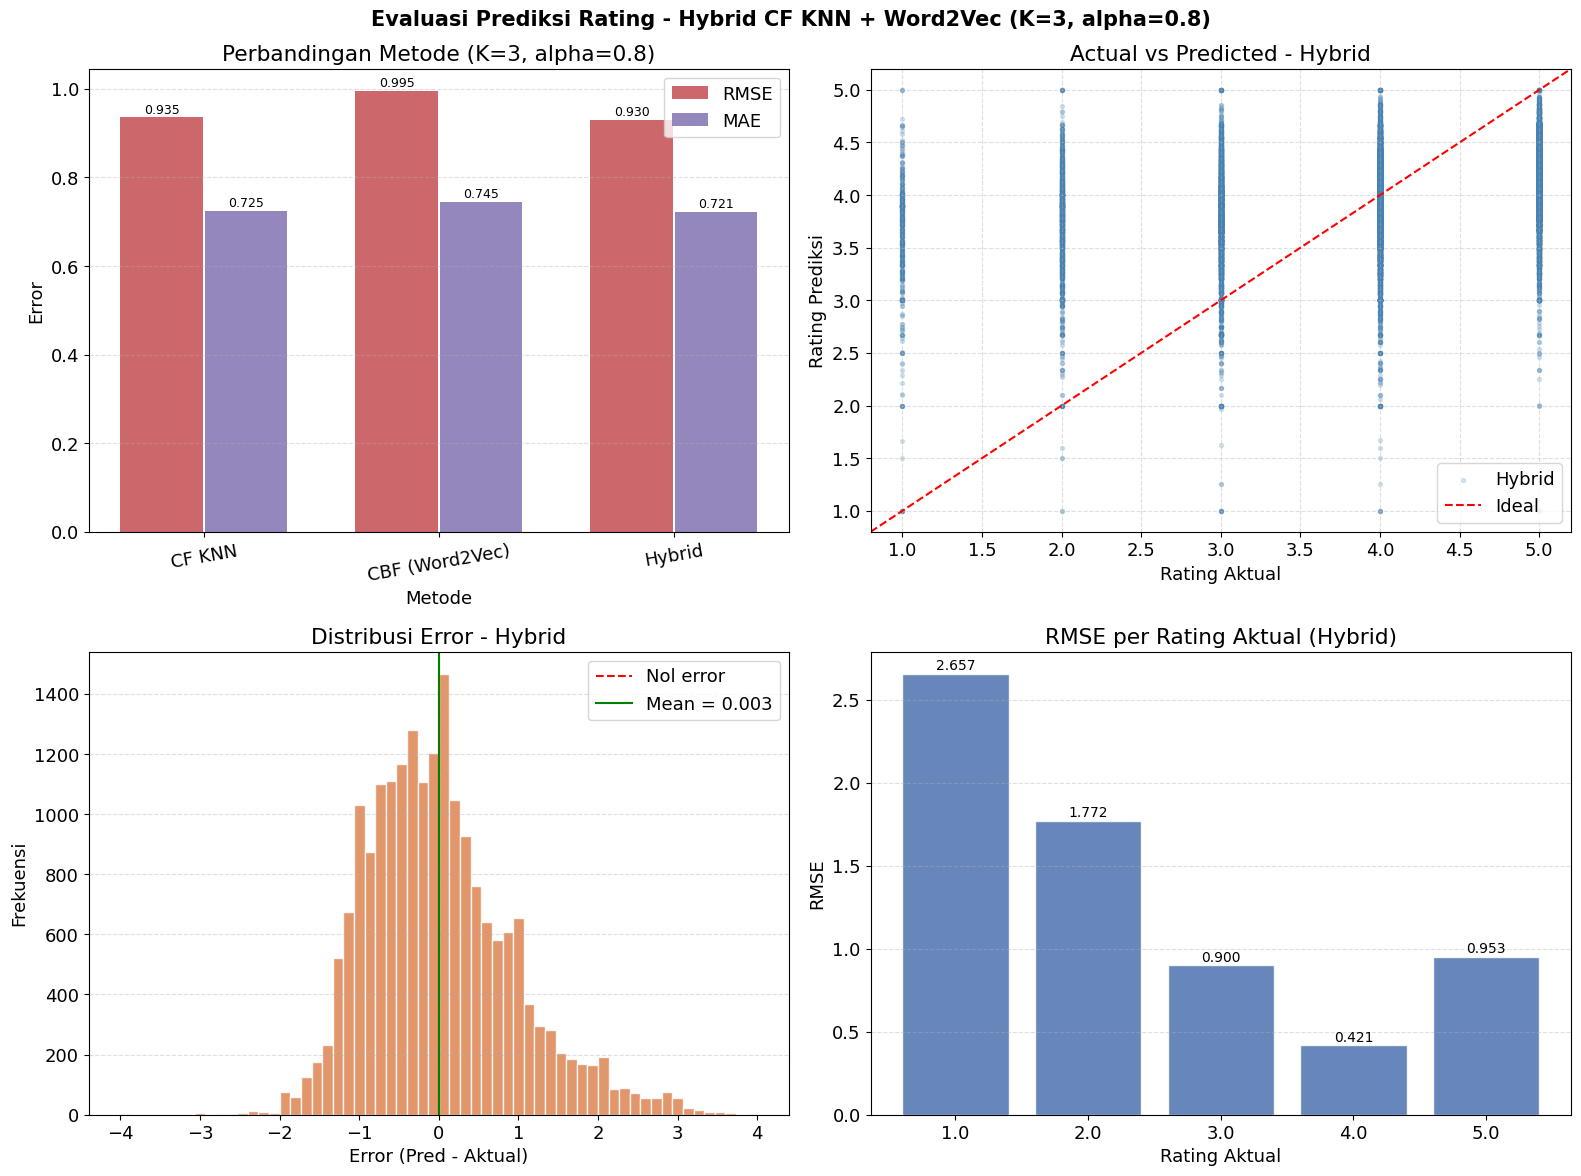

 Disimpan: data/prediksi_rating_cf_hybrid_best.png


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f'Evaluasi Prediksi Rating - Hybrid CF KNN + Word2Vec (K={BEST_K}, alpha={BEST_ALPHA})',
    fontsize=15, fontweight='bold'
)

# -- Plot 1: RMSE & MAE per Metode --
ax        = axes[0, 0]
methods   = ['CF KNN', 'CBF (Word2Vec)', 'Hybrid']
rmse_vals = [rmse_knn, rmse_cbf, rmse_hybrid]
mae_vals  = [mae_knn,  mae_cbf,  mae_hybrid]
x         = np.arange(len(methods))

bars_rmse = ax.bar(x - 0.18, rmse_vals, 0.35, label='RMSE', color='#C44E52', alpha=0.85)
bars_mae  = ax.bar(x + 0.18, mae_vals,  0.35, label='MAE',  color='#8172B2', alpha=0.85)
for bar, v in list(zip(bars_rmse, rmse_vals)) + list(zip(bars_mae, mae_vals)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set(title=f'Perbandingan Metode (K={BEST_K}, alpha={BEST_ALPHA})',
       xlabel='Metode', ylabel='Error')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=10)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

# -- Plot 2: Scatter Actual vs Predicted --
ax    = axes[0, 1]
r_min = float(actuals_best.min()) - 0.2
r_max = float(actuals_best.max()) + 0.2
ax.scatter(actuals_best, preds_hybrid, alpha=0.2, s=8, color='steelblue', label='Hybrid')
ax.plot([r_min, r_max], [r_min, r_max], 'r--', linewidth=1.5, label='Ideal')
ax.set(title='Actual vs Predicted - Hybrid',
       xlabel='Rating Aktual', ylabel='Rating Prediksi',
       xlim=[r_min, r_max], ylim=[r_min, r_max])
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

# -- Plot 3: Distribusi Error --
ax     = axes[1, 0]
errors = preds_hybrid - actuals_best
ax.hist(errors, bins=60, color='#DD8452', edgecolor='white', alpha=0.85)
ax.axvline(0,             color='red',   linestyle='--', linewidth=1.5, label='Nol error')
ax.axvline(errors.mean(), color='green', linestyle='-',  linewidth=1.5,
           label=f'Mean = {errors.mean():.3f}')
ax.set(title='Distribusi Error - Hybrid',
       xlabel='Error (Pred - Aktual)', ylabel='Frekuensi')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

# -- Plot 4: RMSE per Rating Aktual --
ax   = axes[1, 1]
bars = ax.bar([str(r) for r in breakdown.index], breakdown['RMSE'],
              color='#4C72B0', edgecolor='white', alpha=0.85)
for bar, v in zip(bars, breakdown['RMSE']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax.set(title='RMSE per Rating Aktual (Hybrid)',
       xlabel='Rating Aktual', ylabel='RMSE')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
import os
os.makedirs('data', exist_ok=True)
plt.savefig('data/prediksi_rating_cf_hybrid_best.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Disimpan: data/prediksi_rating_cf_hybrid_best.png")

## Simpan Hasil ke CSV

In [24]:
os.makedirs('data', exist_ok=True)

df_eval_out = df_eval.copy()
df_eval_out.insert(0, 'user_id',  test_df['user_id'].values)
df_eval_out.insert(1, 'hotel_id', test_df['hotel_id'].values)
df_eval_out['abs_error'] = df_eval_out['error'].abs().round(4)
for col in ['predicted', 'pred_knn', 'pred_cbf']:
    df_eval_out[col] = df_eval_out[col].round(4)

df_eval_out.to_csv('data/hasil_prediksi_hybrid_best.csv', index=False)
print(" Tersimpan: data/hasil_prediksi_hybrid_best.csv")

print(f"\nRingkasan Akhir -- K={BEST_K}, alpha={BEST_ALPHA}")
print(f"{'Metode':<20} {'RMSE':>8} {'MAE':>8}")
print(f"{'-'*38}")
print(f"{'CF KNN':<20} {rmse_knn:>8.4f} {mae_knn:>8.4f}")
print(f"{'CBF (Word2Vec)':<20} {rmse_cbf:>8.4f} {mae_cbf:>8.4f}")
print(f"{'Hybrid':<20} {rmse_hybrid:>8.4f} {mae_hybrid:>8.4f}")
df_eval_out.head(10)

 Tersimpan: data/hasil_prediksi_hybrid_best.csv

Ringkasan Akhir -- K=3, alpha=0.8
Metode                   RMSE      MAE
--------------------------------------
CF KNN                 0.9355   0.7251
CBF (Word2Vec)         0.9953   0.7450
Hybrid                 0.9304   0.7213


,user_id,hotel_id,actual,predicted,error,pred_knn,pred_cbf,strategy,abs_error
0,FB1032DECE1162CB3556D05F278AAFFD,114575,2.0,4.2667,2.266667,4.3333,4.0000,hybrid(alpha=0.8)_knn_fallback,2.2667
1,FB1032DECE1162CB3556D05F278AAFFD,573340,4.0,4.3153,0.315315,4.3153,4.3153,hybrid(alpha=0.8)_both_fallback,0.3153
2,BA524A238B1171206691A6CC3F28F266,108408,3.0,4.1250,1.125000,4.1250,4.1250,hybrid(alpha=0.8)_both_fallback,1.1250
3,BA524A238B1171206691A6CC3F28F266,93430,3.0,3.8172,0.817204,3.8172,3.8172,hybrid(alpha=0.8)_both_fallback,0.8172
4,BA524A238B1171206691A6CC3F28F266,87620,4.0,3.7579,-0.242105,3.9474,3.0000,hybrid(alpha=0.8)_knn_fallback,0.2421
5,EC6CB11E9DC8761710DDA3CF48DD995F,2322597,5.0,4.9286,-0.071429,4.9286,4.9286,hybrid(alpha=0.8)_both_fallback,0.0714
6,C81AB7D49D98FA410EA191E15F427BEC,111501,1.0,3.7636,2.763636,3.7636,3.7636,hybrid(alpha=0.8)_both_fallback,2.7636
7,C81AB7D49D98FA410EA191E15F427BEC,80668,5.0,4.4667,-0.533333,4.3333,5.0000,hybrid(alpha=0.8)_knn_fallback,0.5333
8,2404E3630B78BB9E8D6583076FBA0742,100613,4.0,3.6667,-0.333333,3.6667,3.6667,hybrid(alpha=0.8)_both_fallback,0.3333
9,2404E3630B78BB9E8D6583076FBA0742,1485961,4.0,4.4500,0.450000,4.5625,4.0000,hybrid(alpha=0.8)_knn_fallback,0.4500


In [25]:
# -- Tabel Perbandingan Model: KNN vs Word2Vec (CBF) vs Hybrid --
df_perbandingan = pd.DataFrame({
    'Model' : ['Collaborative Filtering (KNN)', 'Content-Based Filtering (Word2Vec)', 'Hybrid'],
    'RMSE'  : [rmse_knn, rmse_cbf, rmse_hybrid],
    'MAE'   : [mae_knn, mae_cbf, mae_hybrid],
})

df_perbandingan[['RMSE', 'MAE']] = df_perbandingan[['RMSE', 'MAE']].round(4)

df_perbandingan.to_csv('data/hasil_perbandingan_model.csv', index=False)
print(" Tersimpan: data/hasil_perbandingan_model.csv")
df_perbandingan

 Tersimpan: data/hasil_perbandingan_model.csv


,Model,RMSE,MAE
0,Collaborative Filtering (KNN),0.9355,0.7251
1,Content-Based Filtering (Word2Vec),0.9953,0.7450
2,Hybrid,0.9304,0.7213
